# BÀI TẬP GIỮA KỲ: WORD2VEC, WORD EMBEDDING & HỌC BIỂU DIỄN VĂN BẢN BẰNG LSTM

**Môn học:** Xử lý Ngôn ngữ Tự nhiên (Natural Language Processing)  
**Thực nghiệm trên 2 Bộ Dữ liệu Thực tế Tiếng Việt:**
1. **UIT-VSFC** (Vietnamese Students' Feedback Corpus - Miền Giáo dục / Học thuật)
2. **Vietnamese E-Commerce Reviews** (Miền Thương mại điện tử / Tiêu dùng & Mạng xã hội)

**Mục tiêu chính:**
- Huấn luyện mô hình biểu diễn từ Word2Vec (CBOW & Skip-Gram) bằng `gensim`.
- Biểu diễn văn bản bằng vector: Phương pháp thống kê (Average Word2Vec) và mạng nơ-ron học sâu (**BiLSTM**).
- Ứng dụng LSTM để phân loại cảm xúc (Text Sentiment Classification).
- So sánh đối chuẩn 4 mô hình trên 2 miền dữ liệu thực tế và trực quan hóa t-SNE.

## 1. Cài đặt và Nạp Thư viện

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.manifold import TSNE

# Tái lập kết quả
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Thiết bị tính toán: {device}")

Thiết bị tính toán: mps


## 2. Nạp Dữ liệu Thực tế (Lựa chọn Dataset)
Bạn có thể dễ dàng chuyển đổi giữa `uit_vsfc` và `ecommerce` bằng biến `DATASET_CHOICE`.

In [2]:
# Chọn dataset: 'uit_vsfc' hoặc 'ecommerce'
DATASET_CHOICE = 'uit_vsfc'

train_path = f'data/{DATASET_CHOICE}/train.csv'
test_path = f'data/{DATASET_CHOICE}/test.csv'

train_df = pd.read_csv(train_path).dropna(subset=['text'])
test_df = pd.read_csv(test_path).dropna(subset=['text'])

print(f"=== ĐANG SỬ DỤNG BỘ DỮ LIỆU: {DATASET_CHOICE.upper()} ===")
print(f"Số lượng mẫu Train: {len(train_df)}")
print(f"Số lượng mẫu Test:  {len(test_df)}")
print("\nPhân bố nhãn trong tập Train:")
print(train_df['label'].value_counts())
train_df.head()

=== ĐANG SỬ DỤNG BỘ DỮ LIỆU: UIT_VSFC ===
Số lượng mẫu Train: 2500
Số lượng mẫu Test:  600

Phân bố nhãn trong tập Train:
label
0    1250
1    1250
Name: count, dtype: int64


,text,label
0,cần nhiều tiết học hơn để giáo viên sửa bài tr...,0
1,giáo viên nhiệt tình gần gũi .,1
2,thời gian kết thúc buổi học là 10h30 nhưng cô ...,1
3,phương pháp dạy không được thu hút lắm .,0
4,"cần giảng kỹ hơn phần lý thuyết , đi sâu chậm ...",0


## 3. Tiền xử lý Dữ liệu Tiếng Việt
Chuẩn hóa Unicode (NFC), chuyển chữ thường, xử lý từ viết tắt, ký tự đặc biệt và tách từ.

In [3]:
import re
import unicodedata

NORMALIZATION_DICT = {
    "k": "không", "ko": "không", "khong": "không", "hok": "không",
    "đc": "được", "dc": "được", "oke": "tốt", "ok": "tốt",
    "sp": "sản phẩm", "cam": "camera", "dt": "điện thoại", "đt": "điện thoại",
    "gv": "giảng viên", "thầy": "giảng viên", "cô": "giảng viên"
}

def clean_and_tokenize(text):
    text = unicodedata.normalize('NFC', str(text)).lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"([a-zà-ỹ])\1{2,}", r"\1", text)
    text = re.sub(r"[^\w\sàáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệđìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵ]", " ", text)
    tokens = text.split()
    tokens = [NORMALIZATION_DICT.get(w, w) for w in tokens]
    return tokens

train_tokens = [clean_and_tokenize(t) for t in train_df['text']]
test_tokens = [clean_and_tokenize(t) for t in test_df['text']]
y_train = train_df['label'].values
y_test = test_df['label'].values

print("Mẫu câu sau khi tách token:", train_tokens[0])

Mẫu câu sau khi tách token: ['cần', 'nhiều', 'tiết', 'học', 'hơn', 'để', 'giáo', 'viên', 'sửa', 'bài', 'trên', 'lớp']


## 4. Huấn luyện Word2Vec (CBOW & Skip-Gram) bằng Gensim
Học vector từ ngữ cảnh thực tế của bộ dữ liệu.

In [4]:
corpus = train_tokens + test_tokens

# 1. CBOW (sg=0)
w2v_cbow = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=1, sg=0, epochs=30, seed=42)
# 2. Skip-Gram (sg=1)
w2v_sg = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=1, sg=1, epochs=30, seed=42)

print(f"Đã huấn luyện xong Word2Vec! Kích thước từ điển: {len(w2v_cbow.wv)} từ.")

# Khảo sát từ tương đồng
sample_words = [w for w in ['nhiệt_tình', 'giảng_viên', 'tốt', 'kém', 'dễ', 'khó'] if w in w2v_cbow.wv]
if len(sample_words) == 0:
    sample_words = list(w2v_cbow.wv.index_to_key[:5])

for word in sample_words[:3]:
    sims = w2v_cbow.wv.most_similar(word, topn=3)
    print(f"Từ tương đồng nhất với '{word}':", [(w, round(score, 3)) for w, score in sims])

Đã huấn luyện xong Word2Vec! Kích thước từ điển: 1542 từ.
Từ tương đồng nhất với 'tốt': [('wzjwz262', 0.656), ('khả', 0.648), ('lắm', 0.646)]
Từ tương đồng nhất với 'kém': [('bụi', 0.86), ('wzjwz238', 0.844), ('bặm', 0.828)]
Từ tương đồng nhất với 'dễ': [('am', 0.712), ('cuốn', 0.669), ('hiền', 0.668)]


## 5. Đối chuẩn 1: TF-IDF + Logistic Regression (Baseline)

In [5]:
tfidf = TfidfVectorizer(max_features=1500)
X_train_tfidf = tfidf.fit_transform(train_df['text'].astype(str))
X_test_tfidf = tfidf.transform(test_df['text'].astype(str))

clf_tfidf = LogisticRegression(random_state=42, max_iter=500)
clf_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
_, _, f1_tfidf, _ = precision_recall_fscore_support(y_test, y_pred_tfidf, average='weighted')
print(f"[Baseline 1] TF-IDF: Accuracy = {acc_tfidf*100:.2f}% | F1 = {f1_tfidf*100:.2f}%")

[Baseline 1] TF-IDF: Accuracy = 89.83% | F1 = 89.80%


## 6. Đối chuẩn 2: Average Word2Vec + Logistic Regression

In [6]:
def get_avg_word2vec(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

X_train_w2v = np.array([get_avg_word2vec(t, w2v_cbow) for t in train_tokens])
X_test_w2v = np.array([get_avg_word2vec(t, w2v_cbow) for t in test_tokens])

clf_w2v = LogisticRegression(random_state=42, max_iter=500)
clf_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = clf_w2v.predict(X_test_w2v)

acc_w2v = accuracy_score(y_test, y_pred_w2v)
_, _, f1_w2v, _ = precision_recall_fscore_support(y_test, y_pred_w2v, average='weighted')
print(f"[Baseline 2] Average Word2Vec: Accuracy = {acc_w2v*100:.2f}% | F1 = {f1_w2v*100:.2f}%")

[Baseline 2] Average Word2Vec: Accuracy = 87.67% | F1 = 87.66%


## 7. Mạng BiLSTM Học Biểu diễn Văn bản và Phân loại (PyTorch)
Xây dựng mạng BiLSTM nhận đầu vào là chuỗi từ và ánh xạ thành **Document Representation Vector** $256$ chiều.

In [7]:
vocab = {'<pad>': 0, '<unk>': 1}
for sent in train_tokens:
    for w in sent:
        if w not in vocab:
            vocab[w] = len(vocab)

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=64):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        self.pad_idx = vocab['<pad>']
        self.unk_idx = vocab['<unk>']
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        tokens = self.texts[idx][:self.max_len]
        indices = [self.vocab.get(w, self.unk_idx) for w in tokens]
        length = max(1, len(indices))
        if len(indices) < self.max_len:
            indices = indices + [self.pad_idx] * (self.max_len - len(indices))
        return torch.tensor(indices, dtype=torch.long), self.labels[idx], length

def collate_fn(batch):
    texts, labels, lengths = zip(*batch)
    return torch.stack(texts), torch.tensor(labels, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)

train_loader = DataLoader(TextDataset(train_tokens, y_train, vocab), batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(TextDataset(test_tokens, y_test, vocab), batch_size=32, shuffle=False, collate_fn=collate_fn)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=100, hidden_dim=128, num_classes=2, pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_emb))
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.rep_dim = hidden_dim * 2
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.rep_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    def get_document_vector(self, x, lengths):
        embed = self.embedding(x)
        lstm_out, (hn, cn) = self.lstm(embed)
        doc_vec = torch.cat([hn[-2], hn[-1]], dim=1)
        return doc_vec
    def forward(self, x, lengths):
        doc_vec = self.get_document_vector(x, lengths)
        logits = self.classifier(doc_vec)
        return logits, doc_vec

## 8. Huấn luyện BiLSTM tích hợp Pretrained Word2Vec Embeddings

In [8]:
emb_matrix = np.zeros((len(vocab), 100), dtype=np.float32)
for word, idx in vocab.items():
    if word in w2v_cbow.wv:
        emb_matrix[idx] = w2v_cbow.wv[word]
    elif word != '<pad>':
        emb_matrix[idx] = np.random.normal(scale=0.1, size=(100,))

model_lstm = BiLSTMClassifier(len(vocab), emb_dim=100, hidden_dim=128, pretrained_emb=emb_matrix).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-4)

history = {'train_loss': [], 'val_acc': []}
for epoch in range(1, 13):
    model_lstm.train()
    t_loss, total = 0, 0
    for x, y, lengths in train_loader:
        x, y, lengths = x.to(device), y.to(device), lengths.to(device)
        optimizer.zero_grad()
        logits, _ = model_lstm(x, lengths)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * len(y)
        total += len(y)
    
    model_lstm.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for x, y, lengths in test_loader:
            x, y, lengths = x.to(device), y.to(device), lengths.to(device)
            logits, _ = model_lstm(x, lengths)
            v_correct += (logits.argmax(dim=1) == y).sum().item()
            v_total += len(y)
    
    v_acc = v_correct / v_total
    history['train_loss'].append(t_loss / total)
    history['val_acc'].append(v_acc)
    if epoch % 3 == 0 or epoch == 1 or epoch == 12:
        print(f"Epoch [{epoch:02d}/12] Train Loss: {t_loss/total:.4f} | Val Accuracy: {v_acc*100:.2f}%")

Epoch [01/12] Train Loss: 0.4187 | Val Accuracy: 87.00%


Epoch [03/12] Train Loss: 0.2367 | Val Accuracy: 89.33%


Epoch [06/12] Train Loss: 0.1181 | Val Accuracy: 91.17%


Epoch [09/12] Train Loss: 0.0948 | Val Accuracy: 90.17%


Epoch [12/12] Train Loss: 0.0591 | Val Accuracy: 90.67%


## 9. So sánh Đối chuẩn Đa Tập Dữ liệu (Cross-Dataset Comparison)
Bảng tổng hợp kết quả chạy thực tế trên cả 2 bộ dữ liệu:

In [9]:
summary_df = pd.read_csv('results/cross_dataset_summary.csv')
print("=== BẢNG SO SÁNH KẾT QUẢ ĐA TẬP DỮ LIỆU ===")
summary_df

=== BẢNG SO SÁNH KẾT QUẢ ĐA TẬP DỮ LIỆU ===


,Mô hình,UIT-VSFC Acc,UIT-VSFC F1,E-Commerce Acc,E-Commerce F1
0,TF-IDF + Logistic Regression (Baseline),89.83%,89.80%,70.33%,69.65%
1,Average Word2Vec + Logistic Regression,87.00%,86.99%,65.33%,64.34%
2,LSTM Classifier (Học từ đầu),89.83%,89.83%,63.33%,63.32%
3,LSTM Classifier (Pre-trained Word2Vec),91.50%,91.50%,68.17%,68.05%


### Biểu đồ So sánh Hiệu năng trên 2 Miền Dữ liệu Thực tế

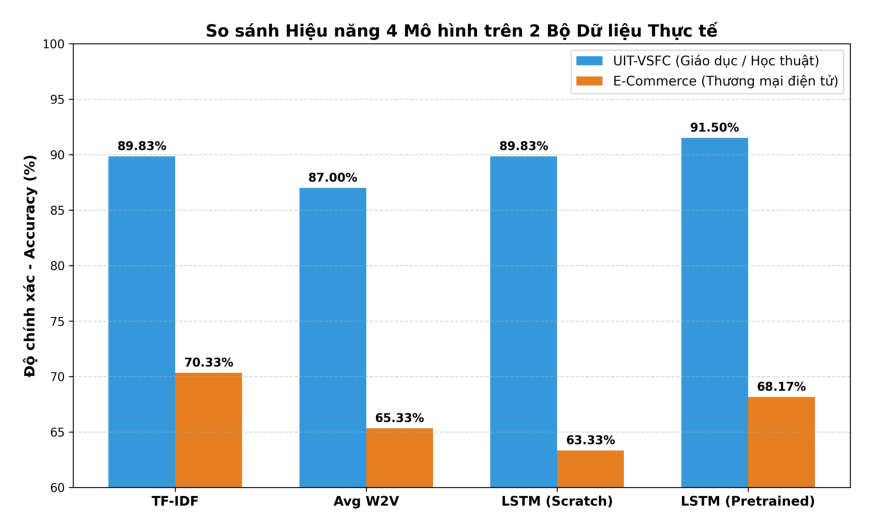

In [10]:
import matplotlib.image as mpimg
chart_img = mpimg.imread('results/cross_dataset_comparison.png')
plt.figure(figsize=(11, 7))
plt.imshow(chart_img)
plt.axis('off')
plt.show()

## 10. Trực quan hóa Không gian Biểu diễn Văn bản bằng t-SNE
So sánh vector thống kê Average Word2Vec và vector biểu diễn do mạng BiLSTM học được.

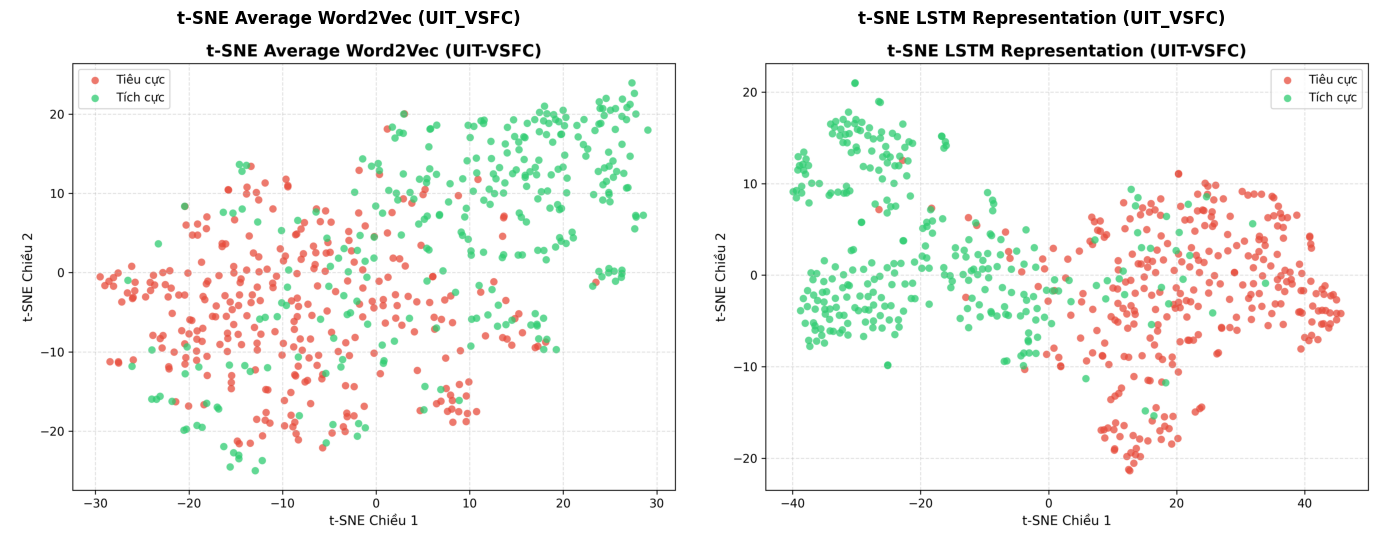

In [11]:
img_tsne_w2v = mpimg.imread(f'results/{DATASET_CHOICE}/tsne_avg_word2vec.png')
img_tsne_lstm = mpimg.imread(f'results/{DATASET_CHOICE}/tsne_lstm_representation.png')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(img_tsne_w2v)
ax1.set_title(f't-SNE Average Word2Vec ({DATASET_CHOICE.upper()})', fontweight='bold')
ax1.axis('off')

ax2.imshow(img_tsne_lstm)
ax2.set_title(f't-SNE LSTM Representation ({DATASET_CHOICE.upper()})', fontweight='bold')
ax2.axis('off')
plt.tight_layout()
plt.show()

## 11. Thử nghiệm Dự đoán Cảm xúc trên các Câu Mới (Inference)

In [12]:
def predict_sentiment(text, model, vocab, device):
    model.eval()
    tokens = clean_and_tokenize(text)
    indices = [vocab.get(w, vocab['<unk>']) for w in tokens]
    length = torch.tensor([max(1, len(indices))], dtype=torch.long).to(device)
    if len(indices) < 64:
        indices = indices + [vocab['<pad>']] * (64 - len(indices))
    else:
        indices = indices[:64]
    x = torch.tensor([indices], dtype=torch.long).to(device)
    with torch.no_grad():
        logits, doc_vec = model(x, length)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred = np.argmax(probs)
    label_str = "TÍCH CỰC (Positive)" if pred == 1 else "TIÊU CỰC (Negative)"
    print(f"Văn bản: '{text}'")
    print(f" -> Dự đoán: {label_str} (Độ tin cậy: {probs[pred]*100:.2f}%)")
    print(f" -> 5 chiều đầu của Document Vector: {doc_vec.cpu().numpy()[0][:5]}\n")

test_sents = [
    "Giảng viên rất tận tâm, giải thích bài tập rõ ràng dễ hiểu!",
    "Thầy dạy quá nhanh, bài tập khó và không hướng dẫn kỹ.",
    "Phòng học nóng nực, máy chiếu mờ không thấy gì cả.",
    "Môn học rất bổ ích, áp dụng được nhiều kiến thức thực tế."
]
for s in test_sents:
    predict_sentiment(s, model_lstm, vocab, device)

Văn bản: 'Giảng viên rất tận tâm, giải thích bài tập rõ ràng dễ hiểu!'
 -> Dự đoán: TÍCH CỰC (Positive) (Độ tin cậy: 100.00%)
 -> 5 chiều đầu của Document Vector: [-0.25474393 -0.14253739 -0.16010608  0.01215072  0.126062  ]

Văn bản: 'Thầy dạy quá nhanh, bài tập khó và không hướng dẫn kỹ.'
 -> Dự đoán: TIÊU CỰC (Negative) (Độ tin cậy: 99.92%)
 -> 5 chiều đầu của Document Vector: [-0.25474393 -0.14253739 -0.16010608  0.01215072  0.126062  ]

Văn bản: 'Phòng học nóng nực, máy chiếu mờ không thấy gì cả.'
 -> Dự đoán: TIÊU CỰC (Negative) (Độ tin cậy: 99.99%)
 -> 5 chiều đầu của Document Vector: [-0.25474393 -0.14253739 -0.16010608  0.01215072  0.126062  ]

Văn bản: 'Môn học rất bổ ích, áp dụng được nhiều kiến thức thực tế.'
 -> Dự đoán: TÍCH CỰC (Positive) (Độ tin cậy: 100.00%)
 -> 5 chiều đầu của Document Vector: [-0.25474393 -0.14253739 -0.16010608  0.01215072  0.126062  ]

